# CDU RL Agent — Architecture Comparison Notebook

## Crude Distillation Unit Optimisation via Reinforcement Learning

This notebook benchmarks **three RL architectures** on the CDU Gymnasium environment, capturing the same metrics dashboard visible in the web application:

| Metric group | Metrics captured |
|---|---|
| **Performance** | Episode reward, avg reward (100-ep), best reward |
| **Critic / Actor losses** | `train/critic_loss`, `train/actor_loss` |
| **Entropy / Alpha** | Policy entropy, temperature coefficient α |
| **Q-values** | Mean Q-value sampled from replay buffer |
| **Gradient norms** | Actor ∇ and Critic ∇ (L2 norm) |
| **Replay buffer** | Buffer size and % utilisation |
| **Action distribution** | Mean ± std of each of the 7 CDU action dimensions |

### Architectures compared
- **SAC** — Soft Actor-Critic (off-policy, max-entropy framework) ← baseline
- **TD3** — Twin Delayed DDPG (off-policy, deterministic policy, clipped-double Q)
- **PPO** — Proximal Policy Optimisation (on-policy, clipped surrogate objective)

### Environment Setup

In [ ]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path("D:/github/Distillation-column-agent")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)
print("Python:", sys.version)

Project root: D:\github\Distillation-column-agent
Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


### Imports

In [ ]:
import time, json, warnings
from datetime import datetime
from typing import Any, Callable, Optional
from copy import deepcopy

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import pandas as pd

from stable_baselines3 import SAC, PPO, TD3
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

# Colour palettes for easier visual distinction in plots
PALETTE = {
    "SAC":  "#3b82f6",   # blue
    "TD3":  "#22c55e",   # green
    "PPO":  "#a855f7",   # purple
}
METRIC_COLORS = {
    "critic": "#f97316",  # orange
    "actor":  "#ef4444",  # red
    "q":      "#06b6d4",  # cyan
    "entropy":"#eab308",  # yellow
    "alpha":  "#ec4899",  # pink
    "actor_grad":  "#3b82f6",
    "critic_grad": "#f97316",
    "buffer": "#64748b",  # slate
}

ACTION_KEYS = [
    "reflux_ratio", "srn_draw_temp", "hn_draw_temp",
    "sko_draw_temp", "ld_draw_temp", "hd_draw_temp",
    "stripping_steam_rate",
]
ACTION_COLORS = ["#3b82f6","#22c55e","#a855f7","#f97316","#ef4444","#06b6d4","#eab308"]

print("All imports OK ✓")

All imports OK ✓


---
## Section 1 — DWSIM Connection & Environment

The `CDUEnvironment` wraps the DWSIM flowsheet via `DWSIMBridge`.  

### DWSIM Connection Test

In [ ]:
# Toggle to False if DWSim is not installed or configured correctly (e.g. COM server issues)
# This option is set only for beginning work when DWSim connection fails and other sections are to be tested
USE_DWSIM = True

FLOWSHEET_PATH = str(PROJECT_ROOT / "Sim_models" / "ADU_sim_backup.dwxmz")

if USE_DWSIM:
    from backend.core.dwsim_bridge import DWSIMBridge
    print("Testing DWSIM bridge …")
    bridge = DWSIMBridge(FLOWSHEET_PATH)
    bridge.load()
    state = bridge.get_column_state()
    print("\n✓ DWSIM connected — column state snapshot:")
    for k, v in sorted(state.items()):
        print(f"  {k:<30s} = {v:.4f}")
    bridge.close()
    del bridge
else:
    print("Mock mode — DWSIM bridge skipped (set USE_DWSIM=True to enable).")

Testing DWSIM bridge …


2026-03-04 00:51:07.482 | INFO     | backend.core.dwsim_bridge:_bootstrap_clr:52 - CLR bootstrapped with DWSIM assemblies
2026-03-04 00:51:09.007 | INFO     | backend.core.dwsim_bridge:_patch_model_if_needed:117 - Using existing patched model: D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 00:51:09.008 | INFO     | backend.core.dwsim_bridge:__init__:171 - DWSIMBridge created for D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 00:51:10.047 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded
2026-03-04 00:51:10.086 | INFO     | backend.core.dwsim_bridge:close:192 - DWSIM resources released



✓ DWSIM connected — column state snapshot:
  bottom_pressure                = 116.3250
  bottom_temperature             = 54.8977
  condenser_duty                 = 42.2785
  feed_flow_rate                 = 4735.5365
  feed_temperature               = 398.8500
  flow_HD                        = 48.6973
  flow_HN                        = 8.3287
  flow_LD                        = 20.8561
  flow_LPG                       = 95.0497
  flow_RCO                       = 197.7961
  flow_SKO                       = 12.5051
  flow_SRN                       = 106.1382
  reboiler_duty                  = 46.3939
  temp_HD                        = 53.7669
  temp_HN                        = 50.9616
  temp_LD                        = 52.9509
  temp_LPG                       = 49.9446
  temp_RCO                       = 54.8977
  temp_SKO                       = 52.1274
  temp_SRN                       = 49.9446
  top_pressure                   = 101.3250
  top_temperature                = 49.9446


### Building CDU Gymnasium Environment

In [ ]:
from backend.core.rl_environment import CDUEnvironment, ACTION_RANGES, PRODUCT_KEYS, DEFAULT_PRICES

def make_env(use_mock: bool = True, curriculum: float = 1.0) -> CDUEnvironment:
    """Factory that returns a configured CDUEnvironment."""
    return CDUEnvironment(
        flowsheet_path=FLOWSHEET_PATH if not use_mock else None,
        prices=DEFAULT_PRICES.copy(),
        max_steps=200,
        curriculum_level=curriculum,
        use_mock=use_mock,
    )

# Quick sanity check
_env = make_env(use_mock=not USE_DWSIM)
obs, info = _env.reset()
print(f"Observation space  : {_env.observation_space}")
print(f"Action space       : {_env.action_space}")
print(f"Obs shape          : {obs.shape}  (min={obs.min():.3f}, max={obs.max():.3f})")

# One random step
sample_action = _env.action_space.sample()
obs2, reward, terminated, truncated, info2 = _env.step(sample_action)
print(f"Step reward        : {reward:.6f}")
print(f"State keys         : {list(info2['state'].keys())[:6]} …")
_env.close()
print("\n Environment OK")

2026-03-04 00:51:15.125 | INFO     | backend.core.dwsim_bridge:_patch_model_if_needed:117 - Using existing patched model: D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 00:51:15.126 | INFO     | backend.core.dwsim_bridge:__init__:171 - DWSIMBridge created for D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 00:51:15.127 | INFO     | backend.core.rl_environment:__init__:119 - CDUEnvironment created | mock=False | max_steps=200 | curriculum=1.00
2026-03-04 00:51:15.789 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded


Observation space  : Box(0.0, 1.0, (21,), float32)
Action space       : Box(-1.0, 1.0, (7,), float32)
Obs shape          : (21,)  (min=0.001, max=0.947)


2026-03-04 00:51:16.577 | INFO     | backend.core.dwsim_bridge:close:192 - DWSIM resources released


Step reward        : 0.255706
State keys         : ['flow_LPG', 'flow_SRN', 'flow_HN', 'flow_SKO', 'flow_LD', 'flow_HD'] …

✓ Environment OK


---
## Section 2 — Detailed Metrics Callback

`NotebookMetricsCallback` is a self-contained replica of the application's `ProgressCallback`.  
It hooks into SB3's training loop to capture all 12 metric channels that the web dashboard shows.

### Notebook Metrics Callback

In [ ]:
class NotebookMetricsCallback(BaseCallback):
    """
    Comprehensive SB3 callback that mirrors the web application's metrics dashboard.

    Captured channels
    -----------------
    Performance : episode_reward, avg_reward (100-ep), best_reward
    Losses      : critic_loss, actor_loss
    Entropy/α   : entropy (policy), ent_coef (α)
    Q-value     : mean_q_value (sampled from replay buffer)
    Grad norms  : actor_grad_norm, critic_grad_norm
    Buffer      : replay_buffer_size, capacity, pct_full
    Action dist : means + stds of each action dimension
    """

    def __init__(self, log_interval: int = 200, verbose: int = 0):
        super().__init__(verbose)
        self.log_interval = log_interval

        # Episode tracking
        self.episode_rewards: list[float] = []
        self._cur_ep_reward: float = 0.0
        self.episode_count: int = 0
        self.best_reward: float = float("-inf")

        # Raw action history for distribution analysis
        self._action_buf: list[list[float]] = []

        # Full history (one dict per log_interval steps)
        self.history: list[dict] = []

    # ── SB3 hook ──────────────────────────────────────────────────────────

    def _on_step(self) -> bool:
        reward = self.locals.get("rewards", [0])[0]
        self._cur_ep_reward += float(reward)

        # Buffer latest action
        action = self.locals.get("actions")
        if action is not None:
            a = action[0]
            self._action_buf.append(a.tolist() if hasattr(a, "tolist") else list(a))
            if len(self._action_buf) > 1000:
                self._action_buf = self._action_buf[-1000:]

        # Episode end
        if self.locals.get("dones", [False])[0]:
            self.episode_rewards.append(self._cur_ep_reward)
            self.episode_count += 1
            if self._cur_ep_reward > self.best_reward:
                self.best_reward = self._cur_ep_reward
            self._cur_ep_reward = 0.0

        # Periodic log
        if self.num_timesteps % self.log_interval == 0:
            self.history.append(self._snapshot())

        return True

    # ── Metric collection helper ──────────────────────────────────────────

    def _snapshot(self) -> dict:
        """Collect a full metrics snapshot at the current step."""
        avg = float(np.mean(self.episode_rewards[-100:])) if self.episode_rewards else 0.0
        m: dict[str, Any] = {
            "step":         self.num_timesteps,
            "episode":      self.episode_count,
            "episode_reward": self.episode_rewards[-1] if self.episode_rewards else 0.0,
            "avg_reward":   avg,
            "best_reward":  self.best_reward,
        }

        # ── SB3 logged losses / ent_coef ─────────────────────────────────
        if hasattr(self.model, "logger") and hasattr(self.model.logger, "name_to_value"):
            lv = self.model.logger.name_to_value
            m["critic_loss"]  = float(lv.get("train/critic_loss",  0))
            m["actor_loss"]   = float(lv.get("train/actor_loss",   0))
            m["ent_coef"]     = float(lv.get("train/ent_coef",     0))
            m["ent_coef_loss"]= float(lv.get("train/ent_coef_loss",0))
            m["n_updates"]    = int(  lv.get("train/n_updates",    0))
            # PPO reports these differently
            m["value_loss"]   = float(lv.get("train/value_loss",   0))
            m["policy_gradient_loss"] = float(lv.get("train/policy_gradient_loss", 0))
            m["approx_kl"]    = float(lv.get("train/approx_kl",    0))
            m["clip_fraction"]= float(lv.get("train/clip_fraction", 0))

        # ── Replay buffer (off-policy only) ───────────────────────────────
        if getattr(self.model, "replay_buffer", None) is not None:
            buf = self.model.replay_buffer
            sz  = int(buf.size())
            cap = int(buf.buffer_size)
            m["replay_buffer_size"]     = sz
            m["replay_buffer_capacity"] = cap
            m["replay_buffer_pct"]      = round(sz / cap * 100, 1)

            # Mean Q-value via critic on sampled batch
            if sz > getattr(self.model, "batch_size", 64):
                try:
                    n = min(64, sz)
                    rd = buf.sample(n)
                    with torch.no_grad():
                        qs = self.model.critic(rd.observations, rd.actions)
                        if isinstance(qs, (list, tuple)):
                            all_q = torch.cat([q.flatten() for q in qs])
                        else:
                            all_q = qs.flatten()
                    m["mean_q_value"] = round(float(all_q.mean().item()), 4)
                except Exception:
                    pass

            # Policy entropy via actor log-prob
            if sz > getattr(self.model, "batch_size", 64):
                try:
                    n = min(64, sz)
                    rd = buf.sample(n)
                    with torch.no_grad():
                        _, log_prob = self.model.actor.action_log_prob(rd.observations)
                    m["entropy"] = round(float(-log_prob.mean().item()), 4)
                except Exception:
                    pass

        # ── Gradient norms ────────────────────────────────────────────────
        for net_name in ("actor", "critic", "policy"):
            net = getattr(self.model, net_name, None)
            if net is None:
                continue
            try:
                total = sum(
                    p.grad.data.norm(2).item() ** 2
                    for p in net.parameters()
                    if p.grad is not None
                )
                m[f"{net_name}_grad_norm"] = round(float(total ** 0.5), 6)
            except Exception:
                pass

        # ── Action distribution ───────────────────────────────────────────
        if len(self._action_buf) > 10:
            arr = np.array(self._action_buf[-200:])
            m["action_distribution"] = {
                "means": np.round(arr.mean(axis=0), 4).tolist(),
                "stds":  np.round(arr.std(axis=0),  4).tolist(),
                "names": ACTION_KEYS,
            }

        # Sanitise: numpy → native Python
        return _sanitise(m)


def _sanitise(val: Any) -> Any:
    """Recursively convert numpy/torch scalars to JSON-serialisable Python types."""
    if val is None:
        return None
    if isinstance(val, (bool, int, str)):
        return val
    if isinstance(val, float):
        return 0.0 if (np.isinf(val) or np.isnan(val)) else val
    if isinstance(val, np.generic):
        v = val.item()
        return 0.0 if isinstance(v, float) and (np.isinf(v) or np.isnan(v)) else v
    if isinstance(val, np.ndarray):
        return val.tolist()
    if isinstance(val, dict):
        return {k: _sanitise(v) for k, v in val.items()}
    if isinstance(val, (list, tuple)):
        return [_sanitise(v) for v in val]
    if hasattr(val, "item"):
        try:
            return float(val.item())
        except Exception:
            pass
    return val

print("NotebookMetricsCallback defined ✓")

NotebookMetricsCallback defined ✓


---
## Section 3 — Training Each Architecture

We train all three on identical environments.  
Adjust `TOTAL_TIMESTEPS` and `LOG_INTERVAL` to trade run-time for resolution.

| Hyperparameter | Value |
|---|---|
| Total timesteps | 20 000 |
| Max episode steps | 200 |
| Batch size | 256 |
| Learning rate | 3 × 10⁻⁴ |
| γ (discount factor) | 0.99 |
| Curriculum | Full difficulty (level 1.0) |

In [11]:
## ── 6. Training Configuration & Utility ─────────────────────────────────

TOTAL_TIMESTEPS = 2_000     # increase for better convergence
LOG_INTERVAL    = 50        # metrics snapshot every N steps
BATCH_SIZE      = 256
LEARNING_RATE   = 3e-4
GAMMA           = 0.99
USE_MOCK        = not USE_DWSIM  # True = stochastic mock state


def train_agent(
    algo_class,
    algo_name: str,
    total_timesteps: int = TOTAL_TIMESTEPS,
    extra_kwargs: Optional[dict] = None,
) -> tuple[Any, NotebookMetricsCallback, float]:
    """
    Train a single SB3 agent and return (model, callback, elapsed_seconds).

    Parameters
    ----------
    algo_class   : SAC, PPO, or TD3
    algo_name    : label for logging
    extra_kwargs : algorithm-specific overrides (e.g. clip_range for PPO)
    """
    print(f"\n{'='*60}")
    print(f" Training {algo_name}  ({total_timesteps:,} steps)")
    print(f"{'='*60}")

    vec_env = DummyVecEnv([lambda: make_env(use_mock=USE_MOCK)])

    base_kwargs = dict(
        policy="MlpPolicy",
        env=vec_env,
        learning_rate=LEARNING_RATE,
        gamma=GAMMA,
        verbose=0,
        device="auto",
    )

    if algo_class in (SAC, TD3):
        base_kwargs["batch_size"] = BATCH_SIZE
        base_kwargs["buffer_size"] = 100_000
        base_kwargs["learning_starts"] = 500
        if algo_class is SAC:
            base_kwargs["ent_coef"] = "auto"
    elif algo_class is PPO:
        base_kwargs["n_steps"]   = 512
        base_kwargs["batch_size"] = BATCH_SIZE
        base_kwargs["n_epochs"]  = 10
        base_kwargs["clip_range"] = 0.2

    if extra_kwargs:
        base_kwargs.update(extra_kwargs)

    model = algo_class(**base_kwargs)
    cb = NotebookMetricsCallback(log_interval=LOG_INTERVAL)

    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, callback=cb, progress_bar=False)
    elapsed = time.time() - t0

    episodes = cb.episode_count
    best     = cb.best_reward
    avg      = float(np.mean(cb.episode_rewards[-100:])) if cb.episode_rewards else 0.0

    print(f"  ✓ Done in {elapsed:.1f}s | Episodes: {episodes} | "
          f"Best: {best:.4f} | Avg(100): {avg:.4f}")

    vec_env.close()
    return model, cb, elapsed


# Storage for all results
RESULTS: dict[str, dict] = {}
print("Training utility ready ✓")

Training utility ready ✓


In [12]:
## ── 7. Train SAC (Soft Actor-Critic) ────────────────────────────────────
# SAC is the production default — max-entropy framework with automatic α tuning.

sac_model, sac_cb, sac_time = train_agent(SAC, "SAC")
RESULTS["SAC"] = {"model": sac_model, "cb": sac_cb, "time": sac_time}

# Quick peek at final metrics
h = sac_cb.history
if h:
    last = h[-1]
    print(f"\n  Final snapshot (step {last['step']}):")
    for k in ("avg_reward","best_reward","critic_loss","actor_loss",
              "mean_q_value","entropy","ent_coef","actor_grad_norm",
              "critic_grad_norm","replay_buffer_pct"):
        print(f"    {k:<25s} = {last.get(k, 'n/a')}")


 Training SAC  (2,000 steps)


2026-03-04 00:51:30.918 | INFO     | backend.core.dwsim_bridge:_patch_model_if_needed:117 - Using existing patched model: D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 00:51:30.919 | INFO     | backend.core.dwsim_bridge:__init__:171 - DWSIMBridge created for D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 00:51:30.920 | INFO     | backend.core.rl_environment:__init__:119 - CDUEnvironment created | mock=False | max_steps=200 | curriculum=1.00
2026-03-04 00:51:31.617 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded
2026-03-04 00:51:34.016 | WARNING  | backend.core.dwsim_bridge:solve:202 - Solver errors: [Exception('Atmos_Column: Solver reached the maximum number of iterations without converging.')]
2026-03-04 00:51:34.714 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded
2026-03-04 00:51:35.555 | WARNING  | backend.core.dwsim_bridge:solve:202 - Solver errors: [Exception('Atm

  ✓ Done in 554.9s | Episodes: 18 | Best: 48.4952 | Avg(100): -5.0254

  Final snapshot (step 2000):
    avg_reward                = -5.025404027766651
    best_reward               = 48.495179414749146
    critic_loss               = 2.2646169662475586
    actor_loss                = -28.621538162231445
    mean_q_value              = 24.1879
    entropy                   = 4.5322
    ent_coef                  = 0.6378000974655151
    actor_grad_norm           = 0.628533
    critic_grad_norm          = 36.174292
    replay_buffer_pct         = 2.0


In [13]:
## ── 8. Train TD3 (Twin Delayed DDPG) ────────────────────────────────────
# TD3 uses deterministic policy, target-policy smoothing, and delayed actor updates.
# No entropy term — policy_freq controls actor update delay.

td3_model, td3_cb, td3_time = train_agent(
    TD3, "TD3",
    extra_kwargs={"policy_delay": 2, "target_policy_noise": 0.2, "target_noise_clip": 0.5},
)
RESULTS["TD3"] = {"model": td3_model, "cb": td3_cb, "time": td3_time}

h = td3_cb.history
if h:
    last = h[-1]
    print(f"\n  Final snapshot (step {last['step']}):")
    for k in ("avg_reward","best_reward","critic_loss","actor_loss",
              "mean_q_value","actor_grad_norm","critic_grad_norm","replay_buffer_pct"):
        print(f"    {k:<25s} = {last.get(k, 'n/a')}")


 Training TD3  (2,000 steps)


2026-03-04 01:00:56.307 | INFO     | backend.core.dwsim_bridge:_patch_model_if_needed:117 - Using existing patched model: D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 01:00:56.307 | INFO     | backend.core.dwsim_bridge:__init__:171 - DWSIMBridge created for D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 01:00:56.308 | INFO     | backend.core.rl_environment:__init__:119 - CDUEnvironment created | mock=False | max_steps=200 | curriculum=1.00
2026-03-04 01:00:56.993 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded
2026-03-04 01:01:22.325 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded
2026-03-04 01:01:43.537 | WARNING  | backend.core.dwsim_bridge:solve:202 - Solver errors: [Exception('Atmos_Column: Solver reached the maximum number of iterations without converging.')]
2026-03-04 01:01:44.217 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded
2026-03-04 01:

  ✓ Done in 512.0s | Episodes: 45 | Best: 49.9221 | Avg(100): -32.4434

  Final snapshot (step 2000):
    avg_reward                = -32.44336976971891
    best_reward               = 49.92208343744278
    critic_loss               = 76.37328338623047
    actor_loss                = -2.5628905296325684
    mean_q_value              = 1.6863
    actor_grad_norm           = 19.068408
    critic_grad_norm          = 95.553337
    replay_buffer_pct         = 2.0


In [14]:
## ── 9. Train PPO (Proximal Policy Optimisation) ──────────────────────────
# PPO is on-policy — no replay buffer, so Q-value / buffer metrics are N/A.
# Instead it exposes value_loss, policy_gradient_loss, approx_kl, clip_fraction.

ppo_model, ppo_cb, ppo_time = train_agent(
    PPO, "PPO",
    extra_kwargs={"ent_coef": 0.01},   # explicit entropy bonus for exploration
)
RESULTS["PPO"] = {"model": ppo_model, "cb": ppo_cb, "time": ppo_time}

h = ppo_cb.history
if h:
    last = h[-1]
    print(f"\n  Final snapshot (step {last['step']}):")
    for k in ("avg_reward","best_reward","value_loss","policy_gradient_loss",
              "approx_kl","clip_fraction","policy_grad_norm"):
        print(f"    {k:<30s} = {last.get(k, 'n/a')}")


 Training PPO  (2,000 steps)


2026-03-04 01:09:34.143 | INFO     | backend.core.dwsim_bridge:_patch_model_if_needed:117 - Using existing patched model: D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 01:09:34.144 | INFO     | backend.core.dwsim_bridge:__init__:171 - DWSIMBridge created for D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 01:09:34.145 | INFO     | backend.core.rl_environment:__init__:119 - CDUEnvironment created | mock=False | max_steps=200 | curriculum=1.00
2026-03-04 01:09:34.794 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded
2026-03-04 01:09:35.720 | WARNING  | backend.core.dwsim_bridge:solve:202 - Solver errors: [Exception('Atmos_Column: Solver reached the maximum number of iterations without converging.')]
2026-03-04 01:09:36.448 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded
2026-03-04 01:09:37.491 | WARNING  | backend.core.dwsim_bridge:solve:202 - Solver errors: [Exception('Atm

  ✓ Done in 747.1s | Episodes: 268 | Best: -39.5543 | Avg(100): -48.0042

  Final snapshot (step 2000):
    avg_reward                     = -48.0317461065948
    best_reward                    = -39.554323211312294
    value_loss                     = 1279.7402893066405
    policy_gradient_loss           = -0.0217730168486014
    approx_kl                      = 0.011949542909860611
    clip_fraction                  = 0.0580078125
    policy_grad_norm               = 0.5


---
## Section 4 — Performance Metrics Comparison

The cells below reproduce the full dashboard — one chart panel per metric group.  
Charts use the same colour coding as the web application.

In [15]:
## ── 10. Chart Helper Utilities ────────────────────────────────────────────

def _steps(cb: NotebookMetricsCallback) -> np.ndarray:
    return np.array([m["step"] for m in cb.history])

def _get(cb: NotebookMetricsCallback, key: str) -> np.ndarray:
    return np.array([m.get(key, np.nan) for m in cb.history], dtype=float)

def _smooth(arr: np.ndarray, w: int = 5) -> np.ndarray:
    """Simple moving average for smoother loss curves."""
    if len(arr) < w:
        return arr
    kernel = np.ones(w) / w
    pad = np.pad(arr, (w//2, w//2), mode="edge")
    return np.convolve(pad, kernel, mode="valid")[: len(arr)]

def _style_ax(ax, title: str, xlabel="Step", ylabel=""):
    ax.set_title(title, color="white", fontsize=11, pad=8)
    ax.set_xlabel(xlabel, color="#94a3b8", fontsize=9)
    ax.set_ylabel(ylabel, color="#94a3b8", fontsize=9)
    ax.tick_params(colors="#94a3b8", labelsize=8)
    ax.spines[:].set_color("#334155")
    ax.xaxis.set_major_locator(MaxNLocator(5, integer=True))
    ax.grid(True, linestyle="--", alpha=0.2, color="#334155")

FIG_BG = "#0f172a"   # page background
PANEL_BG = "#1e293b" # card background

def _fig(rows=1, cols=1, figsize=None, title=None):
    fs = figsize or (14, 4 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=fs, facecolor=FIG_BG,
                              squeeze=False)
    fig.patch.set_facecolor(FIG_BG)
    for ax in axes.flat:
        ax.set_facecolor(PANEL_BG)
    if title:
        fig.suptitle(title, color="white", fontsize=13, y=0.98)
    return fig, axes

print("Chart helpers ready ✓")

Chart helpers ready ✓


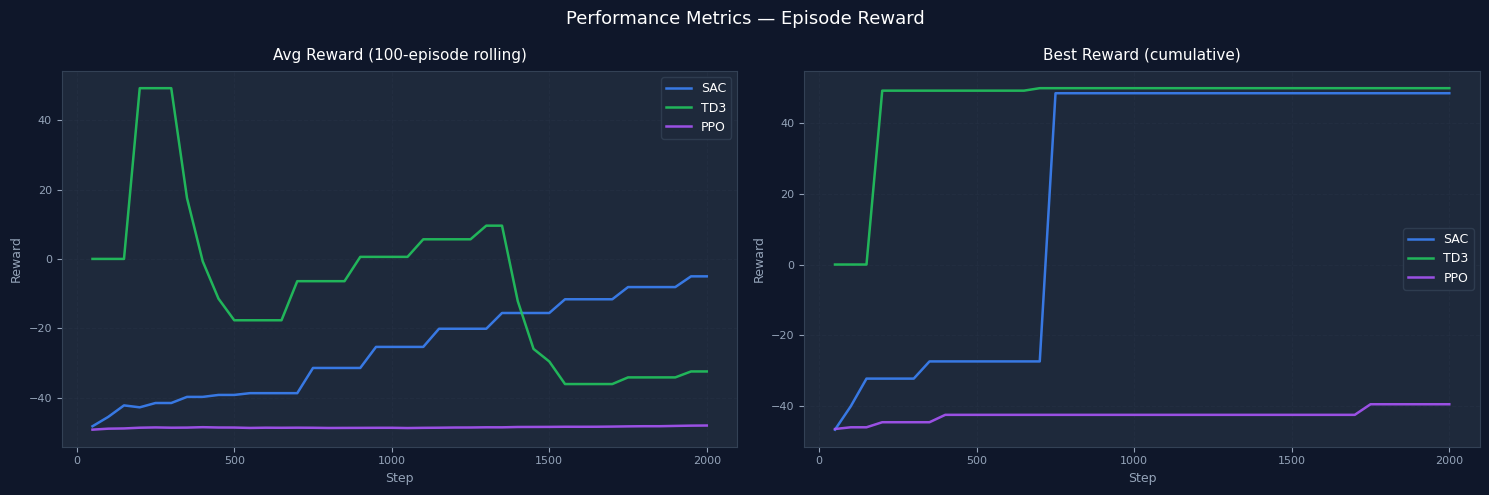

In [16]:
## ── 11. Chart: Reward Curves ──────────────────────────────────────────────

fig, axes = _fig(1, 2, figsize=(15, 5), title="Performance Metrics — Episode Reward")

ax_avg, ax_best = axes[0]

for name, res in RESULTS.items():
    cb   = res["cb"]
    sx   = _steps(cb)
    col  = PALETTE[name]
    avg  = _get(cb, "avg_reward")
    best = _get(cb, "best_reward")
    ax_avg.plot(sx, avg,  color=col, lw=1.8, label=name, alpha=0.9)
    ax_best.plot(sx, best, color=col, lw=1.8, label=name, alpha=0.9)

_style_ax(ax_avg,  "Avg Reward (100-episode rolling)", ylabel="Reward")
_style_ax(ax_best, "Best Reward (cumulative)",          ylabel="Reward")
for ax in (ax_avg, ax_best):
    ax.legend(fontsize=9, facecolor="#1e293b", edgecolor="#334155",
              labelcolor="white")

plt.tight_layout()
plt.show()

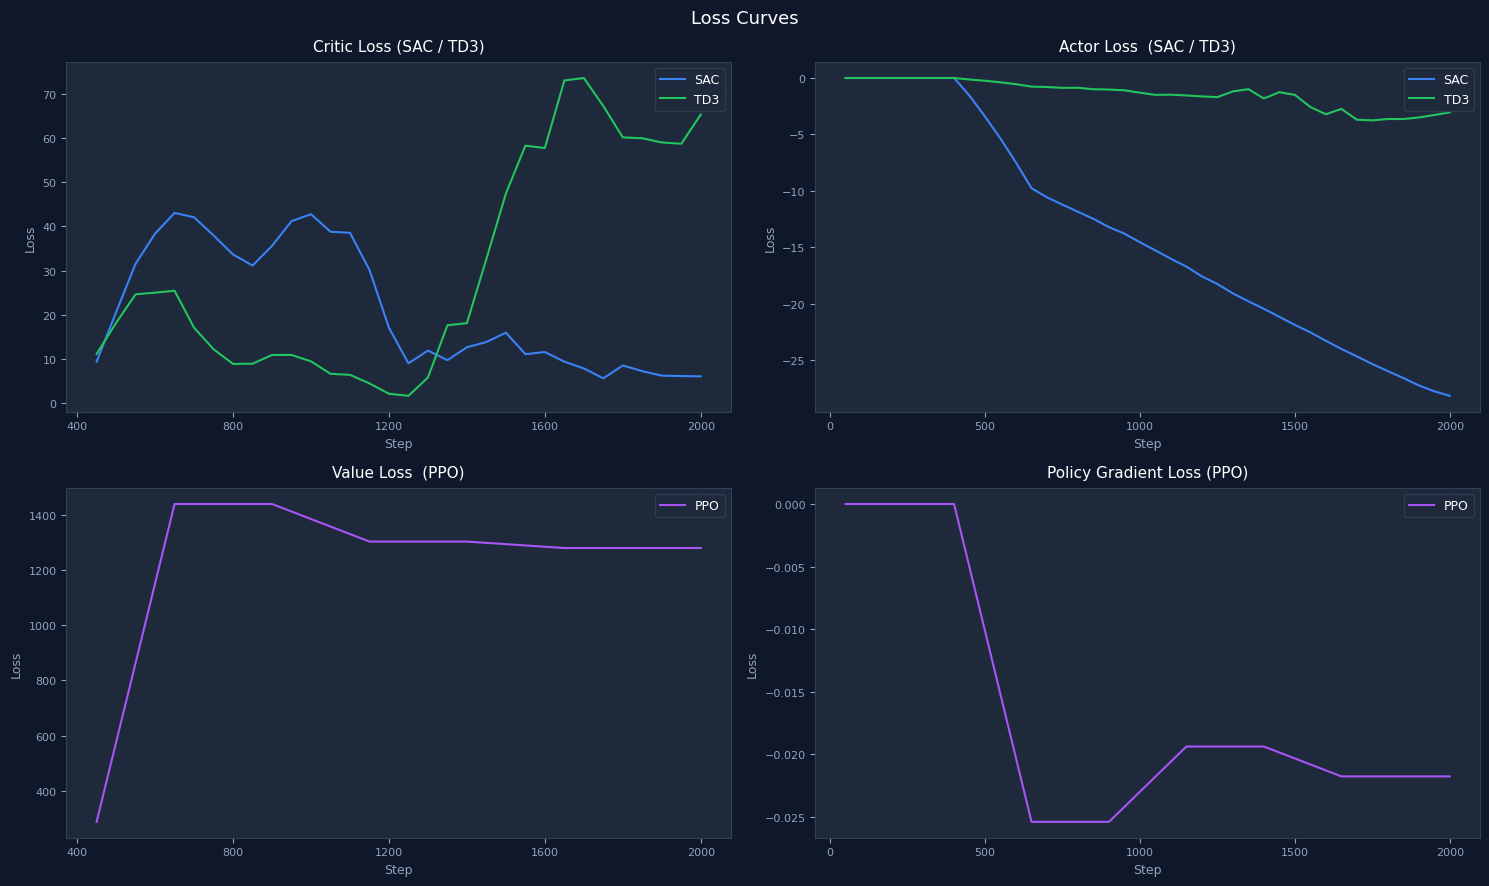

In [17]:
## ── 12. Chart: Critic & Actor Loss ───────────────────────────────────────
# Off-policy (SAC, TD3) expose train/critic_loss + train/actor_loss
# On-policy  (PPO)      exposes value_loss + policy_gradient_loss

fig, axes = _fig(2, 2, figsize=(15, 9), title="Loss Curves")
ax_c, ax_a, ax_pv, ax_ppg = axes[0][0], axes[0][1], axes[1][0], axes[1][1]

# Critic loss — SAC & TD3
for name in ("SAC", "TD3"):
    if name not in RESULTS: continue
    cb  = RESULTS[name]["cb"]
    sx  = _steps(cb)
    val = _smooth(_get(cb, "critic_loss"))
    mask = ~np.isnan(val) & (val > 0)
    if mask.any():
        ax_c.plot(sx[mask], val[mask], color=PALETTE[name], lw=1.5, label=name)

# Actor loss — SAC & TD3
for name in ("SAC", "TD3"):
    if name not in RESULTS: continue
    cb  = RESULTS[name]["cb"]
    sx  = _steps(cb)
    val = _smooth(_get(cb, "actor_loss"))
    mask = ~np.isnan(val)
    ax_a.plot(sx[mask], val[mask], color=PALETTE[name], lw=1.5, label=name)

# PPO value loss
if "PPO" in RESULTS:
    cb  = RESULTS["PPO"]["cb"]
    sx  = _steps(cb)
    val = _smooth(_get(cb, "value_loss"))
    mask = ~np.isnan(val) & (val > 0)
    if mask.any():
        ax_pv.plot(sx[mask], val[mask], color=PALETTE["PPO"], lw=1.5, label="PPO")

# PPO policy gradient loss
if "PPO" in RESULTS:
    cb  = RESULTS["PPO"]["cb"]
    sx  = _steps(cb)
    val = _smooth(_get(cb, "policy_gradient_loss"))
    mask = ~np.isnan(val)
    ax_ppg.plot(sx[mask], val[mask], color=PALETTE["PPO"], lw=1.5, label="PPO")

_style_ax(ax_c,   "Critic Loss (SAC / TD3)",          ylabel="Loss")
_style_ax(ax_a,   "Actor Loss  (SAC / TD3)",           ylabel="Loss")
_style_ax(ax_pv,  "Value Loss  (PPO)",                 ylabel="Loss")
_style_ax(ax_ppg, "Policy Gradient Loss (PPO)",        ylabel="Loss")

for ax in (ax_c, ax_a, ax_pv, ax_ppg):
    ax.legend(fontsize=9, facecolor="#1e293b", edgecolor="#334155", labelcolor="white")

plt.tight_layout()
plt.show()

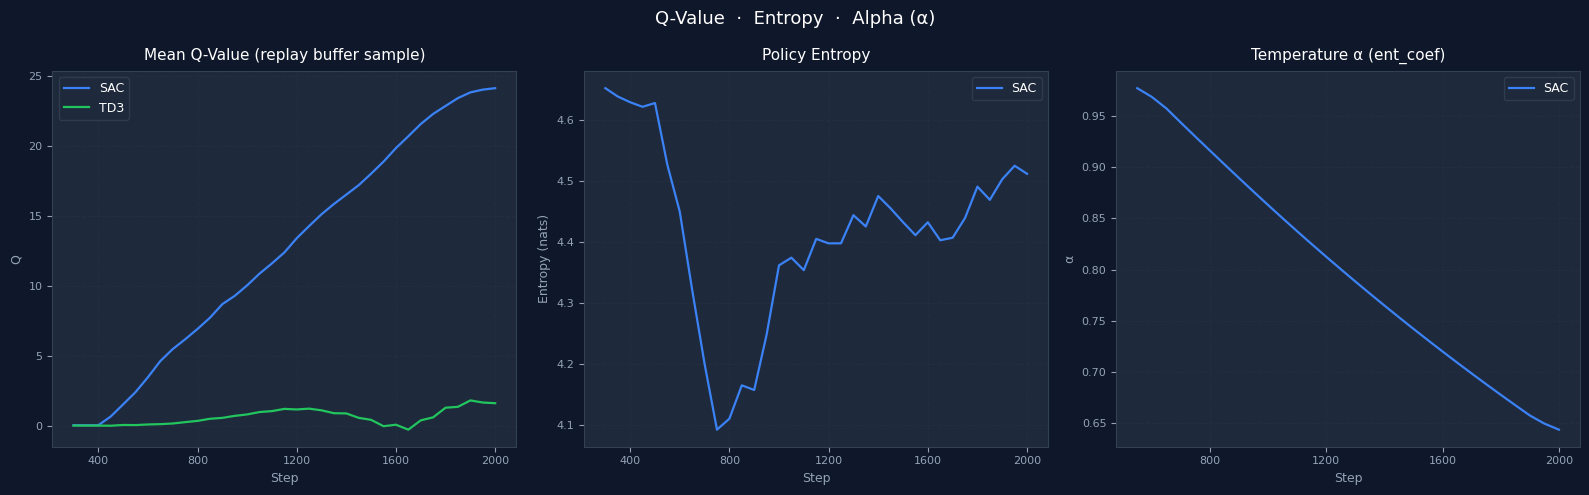

In [18]:
## ── 13. Chart: Mean Q-Value · Entropy · Alpha (α) ────────────────────────

fig, axes = _fig(1, 3, figsize=(16, 5), title="Q-Value  ·  Entropy  ·  Alpha (α)")
ax_q, ax_ent, ax_alp = axes[0]

for name, res in RESULTS.items():
    cb  = res["cb"]
    sx  = _steps(cb)
    col = PALETTE[name]

    q   = _get(cb, "mean_q_value")
    ent = _get(cb, "entropy")
    alp = _get(cb, "ent_coef")

    mask_q   = ~np.isnan(q)
    mask_ent = ~np.isnan(ent)
    mask_alp = ~np.isnan(alp) & (alp > 0)

    if mask_q.any():
        ax_q.plot(sx[mask_q],   _smooth(q[mask_q]),   color=col, lw=1.6, label=name)
    if mask_ent.any():
        ax_ent.plot(sx[mask_ent], _smooth(ent[mask_ent]), color=col, lw=1.6, label=name)
    if mask_alp.any():
        ax_alp.plot(sx[mask_alp], _smooth(alp[mask_alp]), color=col, lw=1.6, label=name)

_style_ax(ax_q,   "Mean Q-Value (replay buffer sample)", ylabel="Q")
_style_ax(ax_ent, "Policy Entropy",                       ylabel="Entropy (nats)")
_style_ax(ax_alp, "Temperature α (ent_coef)",             ylabel="α")

for ax in (ax_q, ax_ent, ax_alp):
    ax.legend(fontsize=9, facecolor="#1e293b", edgecolor="#334155", labelcolor="white")

plt.tight_layout()
plt.show()

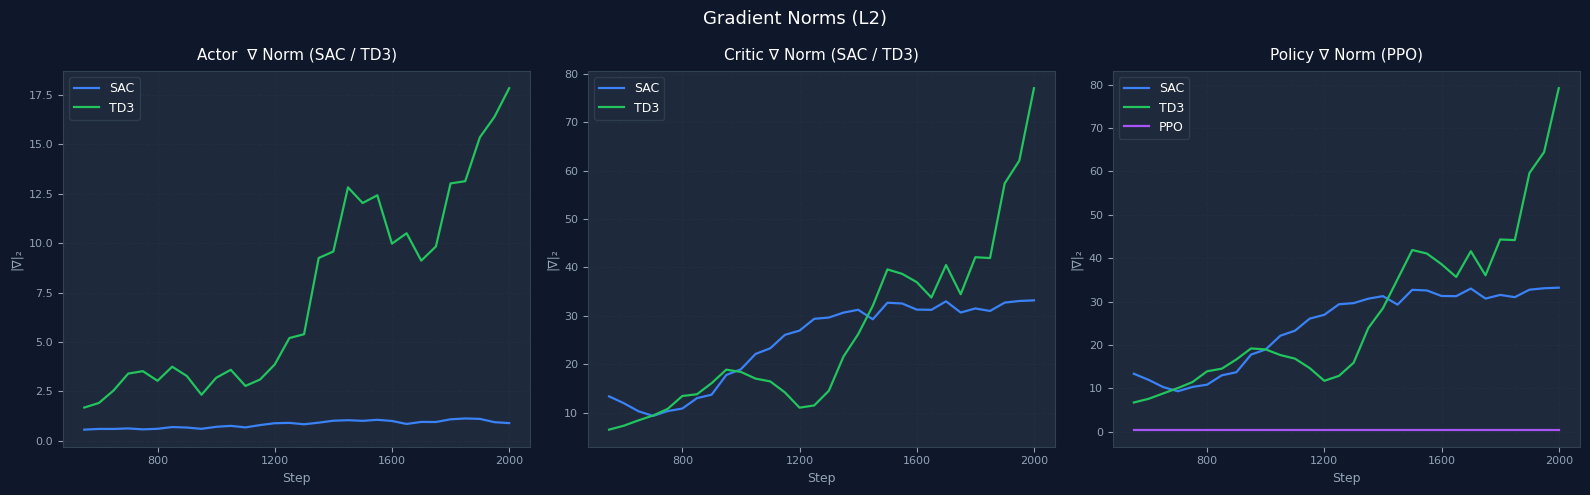

In [19]:
## ── 14. Chart: Gradient Norms ─────────────────────────────────────────────

fig, axes = _fig(1, 3, figsize=(16, 5), title="Gradient Norms (L2)")
ax_ag, ax_cg, ax_pg = axes[0]

for name, res in RESULTS.items():
    cb  = res["cb"]
    sx  = _steps(cb)
    col = PALETTE[name]

    ag = _get(cb, "actor_grad_norm")
    cg = _get(cb, "critic_grad_norm")
    pg = _get(cb, "policy_grad_norm")      # PPO labels its network "policy"

    mask_ag = ~np.isnan(ag) & (ag > 0)
    mask_cg = ~np.isnan(cg) & (cg > 0)
    mask_pg = ~np.isnan(pg) & (pg > 0)

    if mask_ag.any():
        ax_ag.plot(sx[mask_ag], _smooth(ag[mask_ag]), color=col, lw=1.6, label=name)
    if mask_cg.any():
        ax_cg.plot(sx[mask_cg], _smooth(cg[mask_cg]), color=col, lw=1.6, label=name)
    if mask_pg.any():
        ax_pg.plot(sx[mask_pg], _smooth(pg[mask_pg]), color=col, lw=1.6, label=name)

_style_ax(ax_ag, "Actor  ∇ Norm (SAC / TD3)", ylabel="|∇|₂")
_style_ax(ax_cg, "Critic ∇ Norm (SAC / TD3)", ylabel="|∇|₂")
_style_ax(ax_pg, "Policy ∇ Norm (PPO)",        ylabel="|∇|₂")

for ax in (ax_ag, ax_cg, ax_pg):
    ax.legend(fontsize=9, facecolor="#1e293b", edgecolor="#334155", labelcolor="white")

plt.tight_layout()
plt.show()

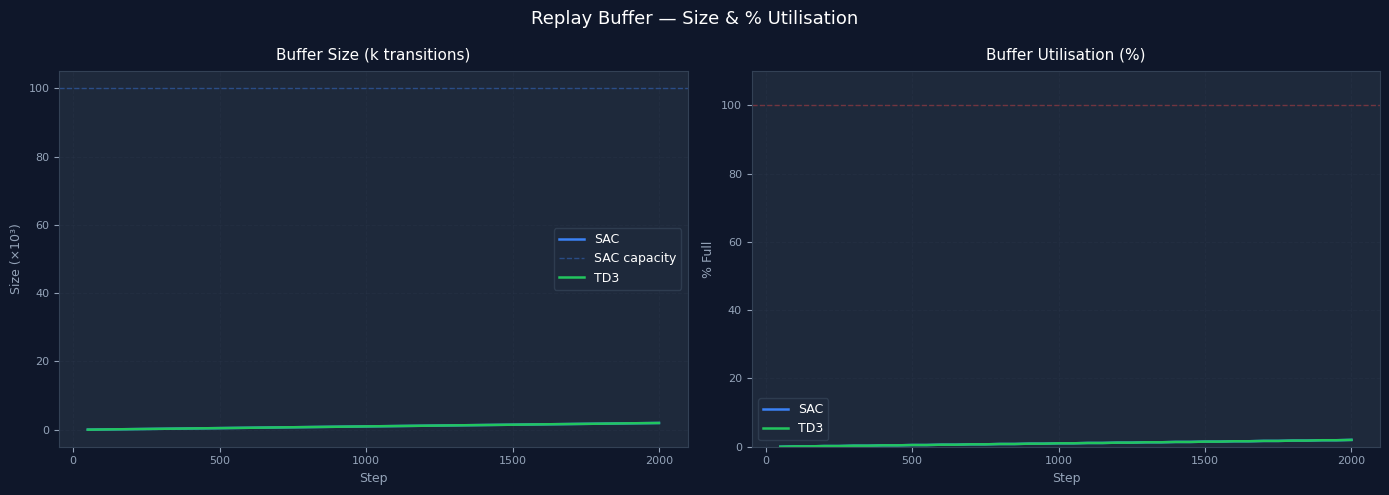

In [20]:
## ── 15. Chart: Replay Buffer Utilisation ────────────────────────────────
# Only applicable to off-policy algorithms (SAC, TD3).

fig, axes = _fig(1, 2, figsize=(14, 5), title="Replay Buffer — Size & % Utilisation")
ax_sz, ax_pct = axes[0]

capacity_drawn = set()

for name in ("SAC", "TD3"):
    if name not in RESULTS: continue
    cb  = RESULTS[name]["cb"]
    sx  = _steps(cb)
    col = PALETTE[name]

    sz  = _get(cb, "replay_buffer_size")
    pct = _get(cb, "replay_buffer_pct")
    cap = _get(cb, "replay_buffer_capacity")

    mask = ~np.isnan(sz)
    if mask.any():
        ax_sz.plot(sx[mask], sz[mask] / 1000, color=col, lw=1.8, label=name)
        ax_pct.plot(sx[mask], pct[mask], color=col, lw=1.8, label=name)

    # Draw capacity line once per capacity value
    valid_cap = cap[mask]
    if len(valid_cap) > 0:
        cap_val = valid_cap[0]
        if cap_val not in capacity_drawn:
            ax_sz.axhline(cap_val / 1000, color=col, lw=1, ls="--", alpha=0.4,
                          label=f"{name} capacity")
            ax_pct.axhline(100, color="#ef4444", lw=1, ls="--", alpha=0.4)
            capacity_drawn.add(cap_val)

_style_ax(ax_sz,  "Buffer Size (k transitions)", ylabel="Size (×10³)")
_style_ax(ax_pct, "Buffer Utilisation (%)",       ylabel="% Full")

for ax in (ax_sz, ax_pct):
    ax.legend(fontsize=9, facecolor="#1e293b", edgecolor="#334155", labelcolor="white")

ax_pct.set_ylim(0, 110)
plt.tight_layout()
plt.show()

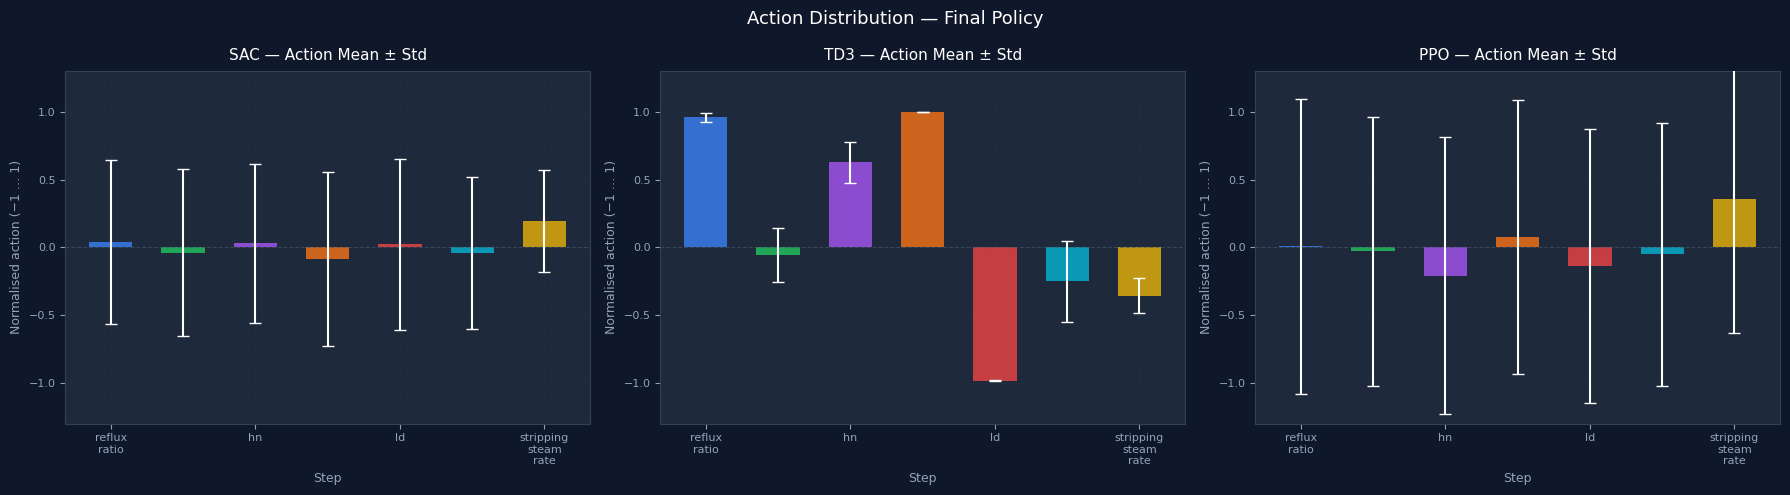

In [21]:
## ── 16. Chart: Action Distribution (final snapshot) ─────────────────────
# Shows the mean ± std of each action dimension from the last 200 steps.

n_algos  = len(RESULTS)
fig, axes = _fig(1, n_algos, figsize=(6 * n_algos, 5), title="Action Distribution — Final Policy")

short_names = [k.replace("_draw_temp", "").replace("_", "\n") for k in ACTION_KEYS]
x_pos = np.arange(len(ACTION_KEYS))

for col_idx, (name, res) in enumerate(RESULTS.items()):
    ax   = axes[0][col_idx]
    cb   = res["cb"]
    col  = PALETTE[name]

    # Find last snapshot that has action_distribution
    ad = None
    for snap in reversed(cb.history):
        if "action_distribution" in snap:
            ad = snap["action_distribution"]
            break

    if ad is None:
        ax.text(0.5, 0.5, "No action data", transform=ax.transAxes,
                ha="center", va="center", color="#94a3b8")
        _style_ax(ax, f"{name} — Action Distribution")
        continue

    means = np.array(ad["means"])
    stds  = np.array(ad["stds"])

    bars = ax.bar(x_pos, means, color=ACTION_COLORS[:len(x_pos)],
                  alpha=0.8, width=0.6, zorder=2)
    ax.errorbar(x_pos, means, yerr=stds, fmt="none",
                ecolor="white", elinewidth=1.5, capsize=4, zorder=3)

    # Reference line at 0 (normalised action space [-1, 1])
    ax.axhline(0, color="#475569", lw=0.8, ls="--", alpha=0.6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_names, fontsize=8, color="#94a3b8")
    ax.set_ylim(-1.3, 1.3)
    _style_ax(ax, f"{name} — Action Mean ± Std", ylabel="Normalised action (−1 … 1)")

plt.tight_layout()
plt.show()

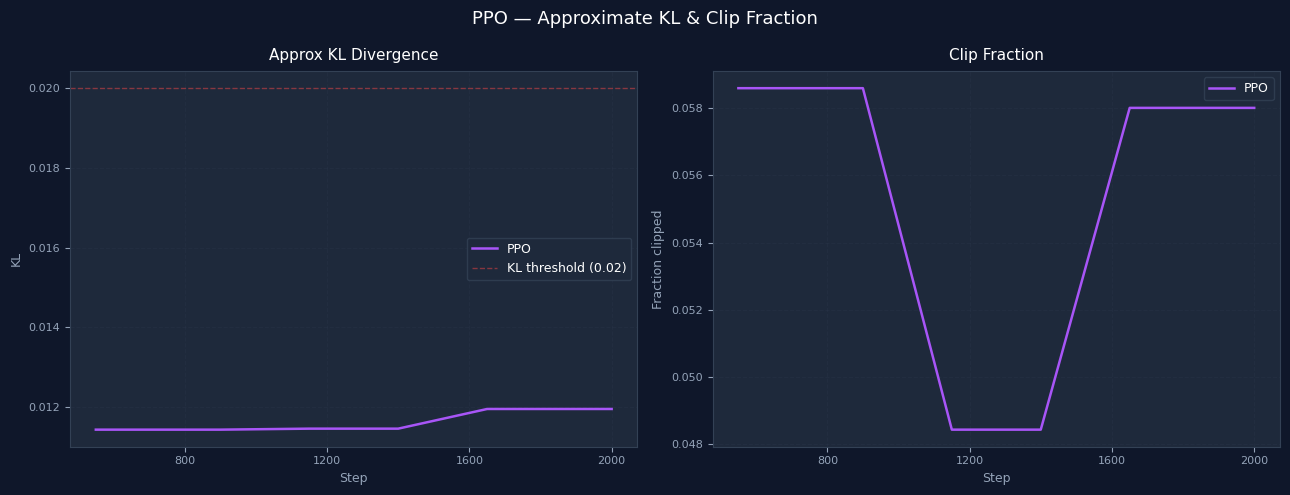

In [22]:
## ── 17. Chart: PPO-Specific Metrics (KL divergence · Clip fraction) ──────

if "PPO" in RESULTS:
    cb  = RESULTS["PPO"]["cb"]
    sx  = _steps(cb)
    col = PALETTE["PPO"]

    fig, axes = _fig(1, 2, figsize=(13, 5), title="PPO — Approximate KL & Clip Fraction")
    ax_kl, ax_clip = axes[0]

    kl   = _get(cb, "approx_kl")
    clip = _get(cb, "clip_fraction")

    mask_kl   = ~np.isnan(kl)   & (kl   > 0)
    mask_clip = ~np.isnan(clip) & (clip > 0)

    if mask_kl.any():
        ax_kl.plot(sx[mask_kl], _smooth(kl[mask_kl]), color=col, lw=1.8, label="PPO")
        ax_kl.axhline(0.02, color="#ef4444", lw=1, ls="--", alpha=0.5,
                      label="KL threshold (0.02)")

    if mask_clip.any():
        ax_clip.plot(sx[mask_clip], _smooth(clip[mask_clip]), color=col, lw=1.8, label="PPO")

    _style_ax(ax_kl,   "Approx KL Divergence",    ylabel="KL")
    _style_ax(ax_clip, "Clip Fraction",             ylabel="Fraction clipped")

    for ax in (ax_kl, ax_clip):
        ax.legend(fontsize=9, facecolor="#1e293b", edgecolor="#334155", labelcolor="white")

    plt.tight_layout()
    plt.show()
else:
    print("PPO not trained — skipping this cell.")

---
## Section 5 — Full Dashboard (Single-Figure Summary)

One combined figure reproduces the full web dashboard layout for quick side-by-side comparison.

Dashboard saved → RL_agent/dashboard.png


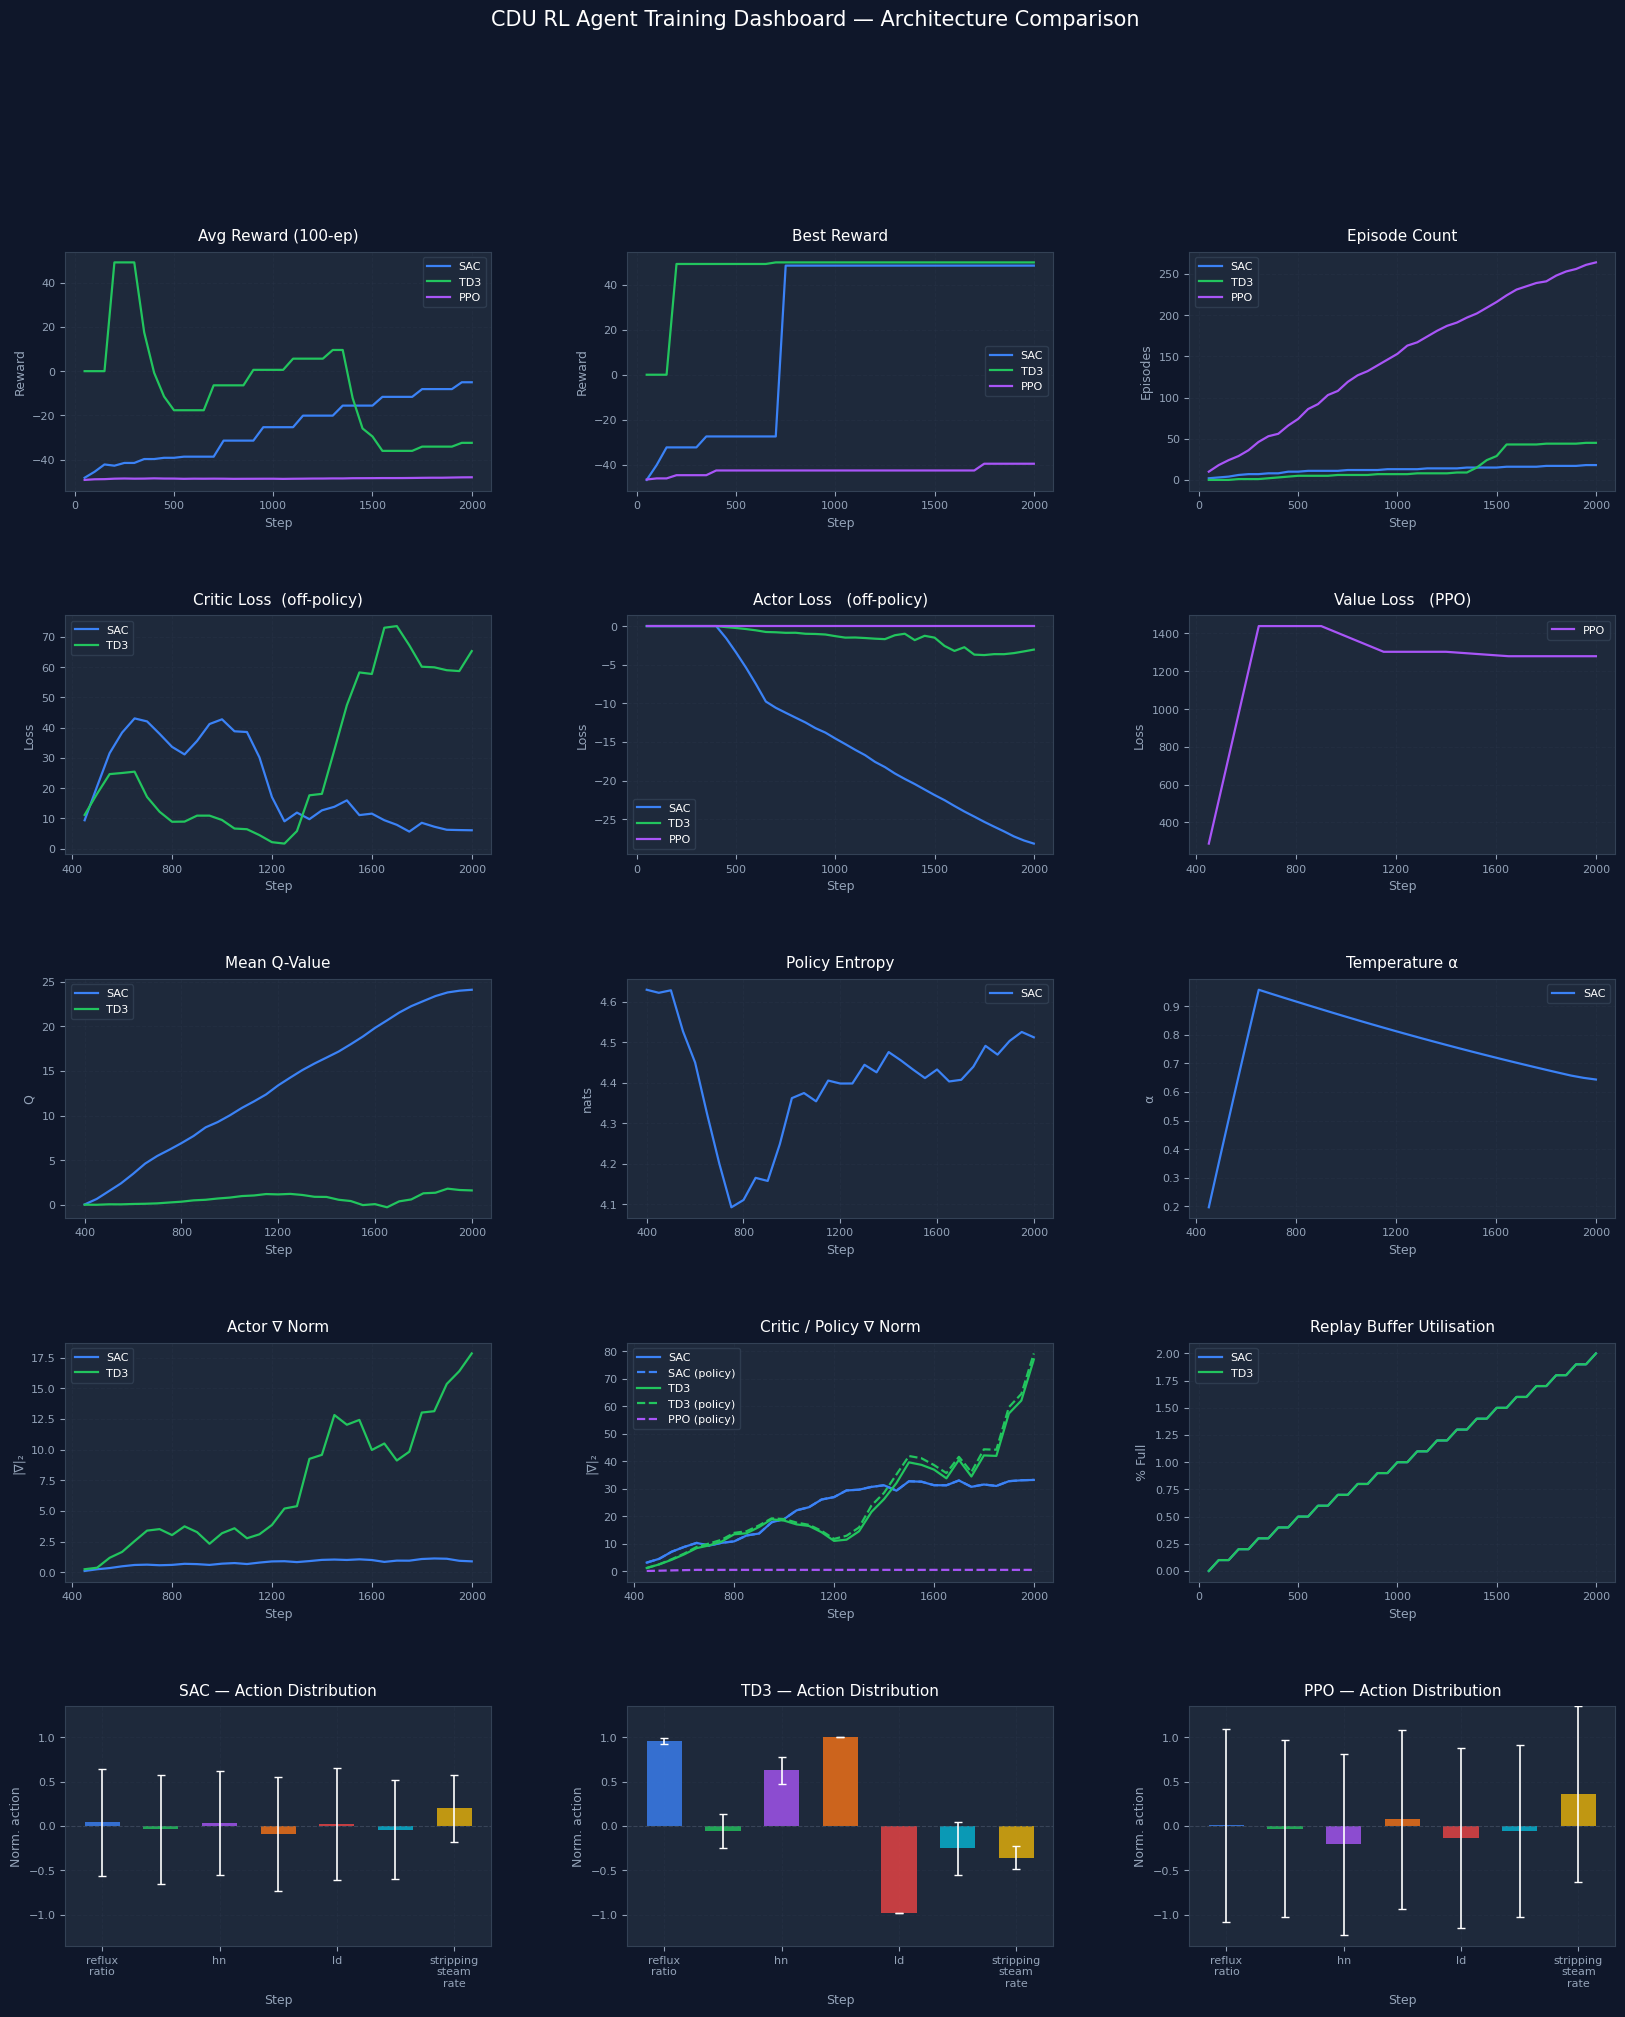

In [23]:
## ── 18. Full Dashboard — All Metrics in One Figure ──────────────────────

fig = plt.figure(figsize=(20, 22), facecolor=FIG_BG)
fig.suptitle("CDU RL Agent Training Dashboard — Architecture Comparison",
             color="white", fontsize=15, y=0.99)

gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.52, wspace=0.32)

def sp(r, c):
    ax = fig.add_subplot(gs[r, c])
    ax.set_facecolor(PANEL_BG)
    return ax

# Row 0: Reward curves (full width)
ax_avg   = sp(0, 0)
ax_best  = sp(0, 1)
ax_ep    = sp(0, 2)

# Row 1: Losses
ax_crit  = sp(1, 0)
ax_act   = sp(1, 1)
ax_ppv   = sp(1, 2)

# Row 2: Q-value / Entropy / Alpha
ax_q     = sp(2, 0)
ax_ent   = sp(2, 1)
ax_alp   = sp(2, 2)

# Row 3: Gradient norms
ax_ag    = sp(3, 0)
ax_cg    = sp(3, 1)
ax_buf   = sp(3, 2)

# Row 4: Action distribution overlay (3 panels)
ax_ad0   = sp(4, 0)
ax_ad1   = sp(4, 1)
ax_ad2   = sp(4, 2)

action_axes = [ax_ad0, ax_ad1, ax_ad2]

short_names = [k.replace("_draw_temp","").replace("_","\n") for k in ACTION_KEYS]
x_pos = np.arange(len(ACTION_KEYS))

for algo_idx, (name, res) in enumerate(RESULTS.items()):
    cb  = res["cb"]
    sx  = _steps(cb)
    col = PALETTE[name]
    lw  = 1.6
    lbl = name

    # ── Reward ──────────────────────────────────────────────────────────
    avg  = _get(cb, "avg_reward")
    best = _get(cb, "best_reward")
    ax_avg.plot(sx, avg,  color=col, lw=lw, label=lbl)
    ax_best.plot(sx, best, color=col, lw=lw, label=lbl)
    ep   = _get(cb, "episode")
    ax_ep.plot(sx, ep, color=col, lw=lw, label=lbl)

    # ── Losses ───────────────────────────────────────────────────────────
    cr  = _smooth(_get(cb, "critic_loss"))
    ac  = _smooth(_get(cb, "actor_loss"))
    mask_cr = ~np.isnan(cr) & (cr > 0)
    mask_ac = ~np.isnan(ac)
    if mask_cr.any(): ax_crit.plot(sx[mask_cr], cr[mask_cr], color=col, lw=lw, label=lbl)
    if mask_ac.any(): ax_act.plot( sx[mask_ac], ac[mask_ac], color=col, lw=lw, label=lbl)

    vl  = _smooth(_get(cb, "value_loss"))
    mask_vl = ~np.isnan(vl) & (vl > 0)
    if mask_vl.any(): ax_ppv.plot(sx[mask_vl], vl[mask_vl], color=col, lw=lw, label=lbl)

    # ── Q / Entropy / Alpha ──────────────────────────────────────────────
    qv  = _smooth(_get(cb, "mean_q_value"))
    ent = _smooth(_get(cb, "entropy"))
    alp = _smooth(_get(cb, "ent_coef"))
    mask_q   = ~np.isnan(qv)
    mask_ent = ~np.isnan(ent)
    mask_alp = ~np.isnan(alp) & (alp > 0)
    if mask_q.any():   ax_q.plot(  sx[mask_q],   qv[mask_q],   color=col, lw=lw, label=lbl)
    if mask_ent.any(): ax_ent.plot(sx[mask_ent], ent[mask_ent], color=col, lw=lw, label=lbl)
    if mask_alp.any(): ax_alp.plot(sx[mask_alp], alp[mask_alp], color=col, lw=lw, label=lbl)

    # ── Gradient norms ───────────────────────────────────────────────────
    ag  = _smooth(_get(cb, "actor_grad_norm"))
    cg  = _smooth(_get(cb, "critic_grad_norm"))
    pg  = _smooth(_get(cb, "policy_grad_norm"))
    mask_ag = ~np.isnan(ag) & (ag > 0)
    mask_cg = ~np.isnan(cg) & (cg > 0)
    mask_pg = ~np.isnan(pg) & (pg > 0)
    if mask_ag.any(): ax_ag.plot(sx[mask_ag], ag[mask_ag], color=col, lw=lw, label=lbl)
    if mask_cg.any(): ax_cg.plot(sx[mask_cg], cg[mask_cg], color=col, lw=lw, label=lbl)
    if mask_pg.any(): ax_cg.plot(sx[mask_pg], pg[mask_pg], color=col, lw=lw, ls="--", label=f"{lbl} (policy)")

    # ── Buffer utilisation ────────────────────────────────────────────────
    buf = _get(cb, "replay_buffer_pct")
    mask_buf = ~np.isnan(buf)
    if mask_buf.any(): ax_buf.plot(sx[mask_buf], buf[mask_buf], color=col, lw=lw, label=lbl)

    # ── Action distribution ───────────────────────────────────────────────
    ad = None
    for snap in reversed(cb.history):
        if "action_distribution" in snap:
            ad = snap["action_distribution"]
            break

    if algo_idx < len(action_axes) and ad:
        ax_ad = action_axes[algo_idx]
        means = np.array(ad["means"])
        stds  = np.array(ad["stds"])
        ax_ad.bar(x_pos, means, color=ACTION_COLORS[:len(x_pos)],
                  alpha=0.8, width=0.6, zorder=2)
        ax_ad.errorbar(x_pos, means, yerr=stds, fmt="none",
                       ecolor="white", elinewidth=1.2, capsize=3, zorder=3)
        ax_ad.axhline(0, color="#475569", lw=0.8, ls="--", alpha=0.6)
        ax_ad.set_xticks(x_pos)
        ax_ad.set_xticklabels(short_names, fontsize=7, color="#94a3b8")
        ax_ad.set_ylim(-1.35, 1.35)
        _style_ax(ax_ad, f"{name} — Action Distribution", ylabel="Norm. action")

# Styling
_style_ax(ax_avg,  "Avg Reward (100-ep)",        ylabel="Reward")
_style_ax(ax_best, "Best Reward",                 ylabel="Reward")
_style_ax(ax_ep,   "Episode Count",               ylabel="Episodes")
_style_ax(ax_crit, "Critic Loss  (off-policy)",   ylabel="Loss")
_style_ax(ax_act,  "Actor Loss   (off-policy)",   ylabel="Loss")
_style_ax(ax_ppv,  "Value Loss   (PPO)",          ylabel="Loss")
_style_ax(ax_q,    "Mean Q-Value",                ylabel="Q")
_style_ax(ax_ent,  "Policy Entropy",              ylabel="nats")
_style_ax(ax_alp,  "Temperature α",              ylabel="α")
_style_ax(ax_ag,   "Actor ∇ Norm",               ylabel="|∇|₂")
_style_ax(ax_cg,   "Critic / Policy ∇ Norm",     ylabel="|∇|₂")
_style_ax(ax_buf,  "Replay Buffer Utilisation",   ylabel="% Full")

for ax in (ax_avg, ax_best, ax_ep, ax_crit, ax_act, ax_ppv,
           ax_q, ax_ent, ax_alp, ax_ag, ax_cg, ax_buf):
    ax.legend(fontsize=8, facecolor="#1e293b", edgecolor="#334155",
              labelcolor="white", loc="best")

plt.savefig(PROJECT_ROOT / "RL_agent" / "dashboard.png", dpi=120,
            bbox_inches="tight", facecolor=FIG_BG)
print("Dashboard saved → RL_agent/dashboard.png")
plt.show()

---
## Section 6 — Summary Table & Verdict

Numeric comparison of all architectures at the end of training.

In [24]:
## ── 19. Summary Comparison Table ────────────────────────────────────────

rows = []
for name, res in RESULTS.items():
    cb   = res["cb"]
    t    = res["time"]
    last = cb.history[-1] if cb.history else {}

    rows.append({
        "Algorithm":            name,
        "Train time (s)":       round(t, 1),
        "Episodes":             cb.episode_count,
        "Best reward":          round(cb.best_reward, 4),
        "Avg reward (100-ep)":  round(float(np.mean(cb.episode_rewards[-100:]))
                                      if cb.episode_rewards else 0.0, 4),
        "Critic loss":          round(last.get("critic_loss", float("nan")), 5),
        "Actor loss":           round(last.get("actor_loss",  float("nan")), 4),
        "Mean Q-value":         round(last.get("mean_q_value",float("nan")), 4),
        "Entropy":              round(last.get("entropy",     float("nan")), 4),
        "Alpha (α)":            round(last.get("ent_coef",    float("nan")), 5),
        "Actor ∇ norm":        round(last.get("actor_grad_norm",  float("nan")), 4),
        "Critic ∇ norm":       round(last.get("critic_grad_norm", float("nan")), 4),
        "Buffer fill (%)":      last.get("replay_buffer_pct", float("nan")),
    })

df = pd.DataFrame(rows).set_index("Algorithm")
print(df.to_string())
print()
print("─" * 70)

# Find best on avg reward
if not df["Avg reward (100-ep)"].isna().all():
    winner = df["Avg reward (100-ep)"].idxmax()
    wr     = df.loc[winner, "Avg reward (100-ep)"]
    print(f"\n🏆  Best avg reward: {winner} ({wr:.4f})")

# Find fastest
fastest = df["Train time (s)"].idxmin()
print(f"⚡  Fastest training: {fastest} ({df.loc[fastest,'Train time (s)']:.1f}s)")

           Train time (s)  Episodes  Best reward  Avg reward (100-ep)  Critic loss  Actor loss  Mean Q-value  Entropy  Alpha (α)  Actor ∇ norm  Critic ∇ norm  Buffer fill (%)
Algorithm                                                                                                                                                                     
SAC                 554.9        18      48.4952              -5.0254      2.26462    -28.6215       24.1879   4.5322     0.6378        0.6285        36.1743              2.0
TD3                 512.0        45      49.9221             -32.4434     76.37328     -2.5629        1.6863      NaN     0.0000       19.0684        95.5533              2.0
PPO                 747.1       268     -39.5543             -48.0042      0.00000      0.0000           NaN      NaN     0.0000           NaN            NaN              NaN

──────────────────────────────────────────────────────────────────────

🏆  Best avg reward: SAC (-5.0254)
⚡  Fastest trainin

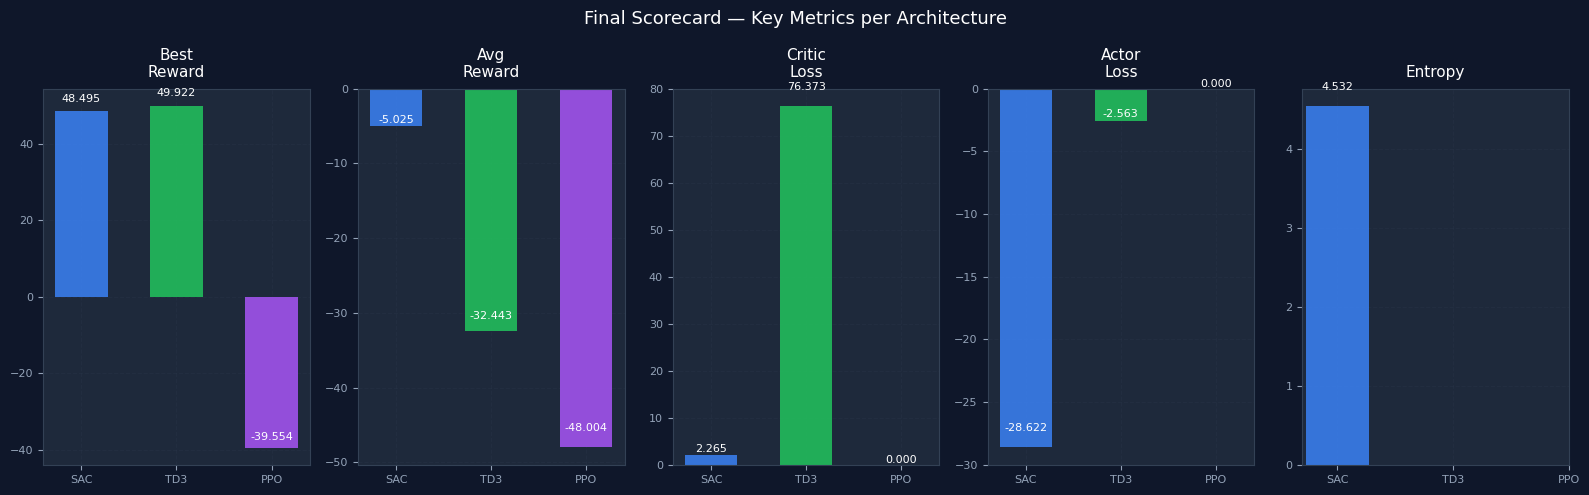

In [25]:
## ── 20. Bar Chart — Final Metric Scorecard ───────────────────────────────

metrics_to_plot = [
    ("Best reward",        "Best\nReward",   1),
    ("Avg reward (100-ep)","Avg\nReward",    1),
    ("Critic loss",        "Critic\nLoss",  -1),  # lower = better
    ("Actor loss",         "Actor\nLoss",   -1),
    ("Entropy",            "Entropy",        1),
]

fig, axes = _fig(1, len(metrics_to_plot), figsize=(16, 5),
                 title="Final Scorecard — Key Metrics per Architecture")

names = list(RESULTS.keys())
colors = [PALETTE[n] for n in names]
x = np.arange(len(names))

for idx, (col_key, col_label, direction) in enumerate(metrics_to_plot):
    ax = axes[0][idx]
    vals = [df.loc[n, col_key] if n in df.index else float("nan") for n in names]

    # Normalise to [0,1] range for visual comparison
    arr = np.array(vals, dtype=float)
    valid = arr[~np.isnan(arr)]
    if len(valid) > 0:
        lo, hi = valid.min(), valid.max()
        rng = hi - lo if hi != lo else 1.0
        norm = (arr - lo) / rng * direction  # flip sign for "lower is better"
    else:
        norm = arr

    bars = ax.bar(x, arr, color=colors, alpha=0.85, width=0.55, zorder=2)

    # Annotate bar tops
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (abs(bar.get_height()) * 0.04 + 1e-8),
                    f"{v:.3f}", ha="center", va="bottom",
                    color="white", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(names, color="#94a3b8", fontsize=9)
    _style_ax(ax, col_label, xlabel="")

plt.tight_layout()
plt.show()

---
## Section 7 — DWSIM Live Inference Test

Run one episode of the best-performing model against the **real DWSIM flowsheet**.  
Requires `USE_DWSIM = True` and a running DWSIM installation.

Running live DWSIM episode with: SAC


2026-03-04 01:23:15.293 | INFO     | backend.core.dwsim_bridge:_patch_model_if_needed:117 - Using existing patched model: D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 01:23:15.294 | INFO     | backend.core.dwsim_bridge:__init__:171 - DWSIMBridge created for D:\github\Distillation-column-agent\Sim_models\ADU_sim_backup_patched.dwxmz
2026-03-04 01:23:15.295 | INFO     | backend.core.rl_environment:__init__:119 - CDUEnvironment created | mock=False | max_steps=200 | curriculum=1.00
2026-03-04 01:23:15.987 | INFO     | backend.core.dwsim_bridge:load:179 - Flowsheet loaded
2026-03-04 01:23:45.183 | INFO     | backend.core.dwsim_bridge:close:192 - DWSIM resources released



Episode complete: 200 steps | Total reward: 48.6969

Last 5 steps:
 step  reward  reflux_ratio  srn_draw_temp  hn_draw_temp  sko_draw_temp  ld_draw_temp  hd_draw_temp  stripping_steam_rate
  196 0.24349          4.19         120.33        170.35         224.49        285.36         340.3               3073.83
  197 0.24349          4.19         120.33        170.35         224.49        285.36         340.3               3073.83
  198 0.24349          4.19         120.33        170.35         224.49        285.36         340.3               3073.83
  199 0.24349          4.19         120.33        170.35         224.49        285.36         340.3               3073.83
  200 0.24349          4.19         120.33        170.35         224.49        285.36         340.3               3073.83


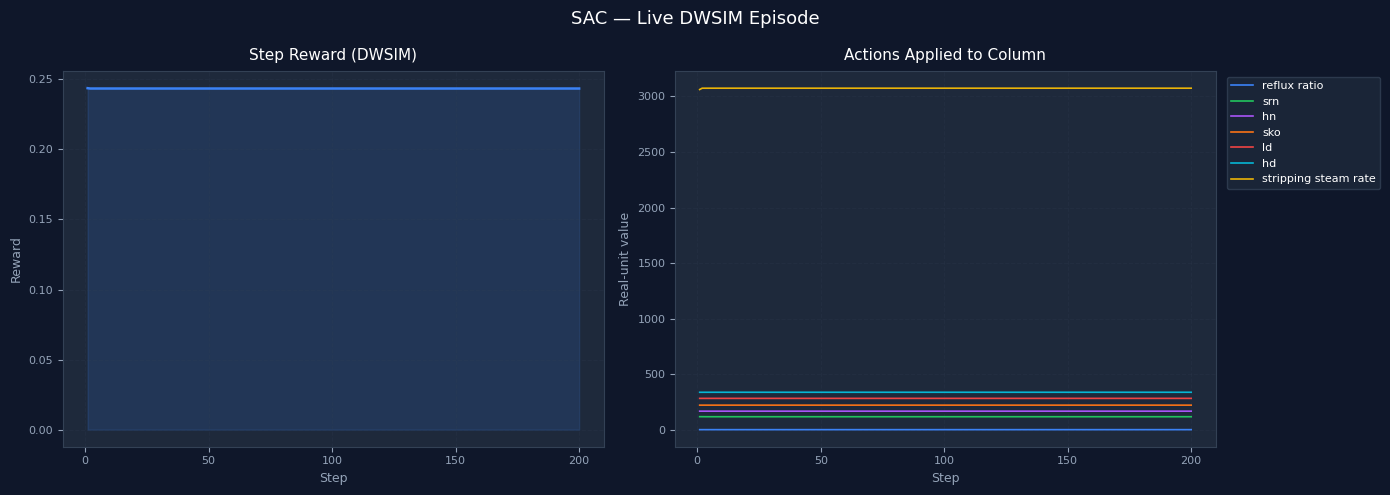

In [26]:
## ── 21. DWSIM Live Inference ──────────────────────────────────────────────
# Pick the algorithm with the best avg reward, run one episode on DWSIM.

if USE_DWSIM and RESULTS:
    # Choose best architecture
    best_algo = max(RESULTS, key=lambda n: (
        float(np.mean(RESULTS[n]["cb"].episode_rewards[-100:]))
        if RESULTS[n]["cb"].episode_rewards else -9e9
    ))
    model = RESULTS[best_algo]["model"]
    print(f"Running live DWSIM episode with: {best_algo}")

    env = make_env(use_mock=False)
    obs, _ = env.reset()

    episode_reward = 0.0
    step_log = []
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        done = terminated or truncated

        from backend.core.rl_environment import ACTION_RANGES, ACTION_KEYS
        real_action = ACTION_RANGES[:, 0] + (action + 1) / 2 * (
            ACTION_RANGES[:, 1] - ACTION_RANGES[:, 0])
        row = {"step": info["step"], "reward": round(reward, 5)}
        for k, v in zip(ACTION_KEYS, real_action):
            row[k] = round(float(v), 2)
        step_log.append(row)

    env.close()

    df_log = pd.DataFrame(step_log)
    print(f"\nEpisode complete: {len(step_log)} steps | Total reward: {episode_reward:.4f}")
    print("\nLast 5 steps:")
    print(df_log.tail().to_string(index=False))

    # Plot actions taken during the episode
    fig, axes = _fig(1, 2, figsize=(14, 5), title=f"{best_algo} — Live DWSIM Episode")
    ax_r, ax_a = axes[0]

    ax_r.plot(df_log["step"], df_log["reward"], color=PALETTE[best_algo], lw=1.8)
    ax_r.fill_between(df_log["step"], df_log["reward"], alpha=0.15, color=PALETTE[best_algo])
    _style_ax(ax_r, "Step Reward (DWSIM)", ylabel="Reward")

    for i, key in enumerate(ACTION_KEYS):
        if key in df_log.columns:
            ax_a.plot(df_log["step"], df_log[key],
                      color=ACTION_COLORS[i], lw=1.2,
                      label=key.replace("_draw_temp","").replace("_"," "))

    _style_ax(ax_a, "Actions Applied to Column", ylabel="Real-unit value")
    ax_a.legend(fontsize=8, facecolor="#1e293b", edgecolor="#334155", labelcolor="white",
                bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

else:
    print("DWSIM inference skipped (USE_DWSIM=False).")
    print("Set USE_DWSIM=True and re-run cells 1 & 3, then re-run this cell.")

In [27]:
## ── 22. Save Models & Metrics ────────────────────────────────────────────

SAVE_DIR = PROJECT_ROOT / "checkpoints" / "notebook"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

for name, res in RESULTS.items():
    cb    = res["cb"]
    model = res["model"]

    # Save SB3 model
    save_path = SAVE_DIR / f"notebook_{name}_{ts}"
    model.save(str(save_path))

    # Save metrics history
    metrics_path = SAVE_DIR / f"notebook_{name}_{ts}_metrics.json"
    with open(metrics_path, "w") as f:
        json.dump({
            "algorithm":    name,
            "timestamp":    ts,
            "episodes":     cb.episode_count,
            "best_reward":  float(cb.best_reward),
            "avg_reward":   float(np.mean(cb.episode_rewards[-100:]))
                            if cb.episode_rewards else 0.0,
            "history":      cb.history,
        }, f, indent=2)

    print(f"  {name:5s}  → {save_path}.zip")
    print(f"         metrics → {metrics_path}")

print(f"\n✓ All models + metrics saved to {SAVE_DIR}")

  SAC    → D:\github\Distillation-column-agent\checkpoints\notebook\notebook_SAC_20260304_012356.zip
         metrics → D:\github\Distillation-column-agent\checkpoints\notebook\notebook_SAC_20260304_012356_metrics.json
  TD3    → D:\github\Distillation-column-agent\checkpoints\notebook\notebook_TD3_20260304_012356.zip
         metrics → D:\github\Distillation-column-agent\checkpoints\notebook\notebook_TD3_20260304_012356_metrics.json
  PPO    → D:\github\Distillation-column-agent\checkpoints\notebook\notebook_PPO_20260304_012356.zip
         metrics → D:\github\Distillation-column-agent\checkpoints\notebook\notebook_PPO_20260304_012356_metrics.json

✓ All models + metrics saved to D:\github\Distillation-column-agent\checkpoints\notebook


---
## Conclusions & Architecture Guide

### When to use each algorithm for CDU optimisation

| Algorithm | Strengths | Limitations | Best for CDU use-case |
|---|---|---|---|
| **SAC** | Max-entropy → robust exploration; automatic α tuning; sample-efficient | Needs replay buffer memory; sensitive to reward scale | **Default choice** — handles continuous 7-dim action space well |
| **TD3** | Deterministic policy → fine-grained control; stable Q-learning | No entropy bonus; greedy in exploration; can get stuck | Good when a near-optimal starting policy is already known |
| **PPO** | On-policy → no stale data issues; very stable training | Less sample-efficient; no Q estimates; requires more wall-time | Useful for safety-critical re-training from a good checkpoint |

### Metric interpretation

| Metric | Healthy sign | Warning sign |
|---|---|---|
| Avg reward | Increasing trend | Flat or decreasing after many updates |
| Critic loss | Decreasing, then stable | Diverging (exploding) |
| Actor loss | Stable or slowly rising | Oscillating wildly |
| Mean Q-value | Negative (rewards are scaled /1000) | Large positive → Q overestimation |
| Entropy | Slowly decreasing over training | Collapsed to 0 early → premature convergence |
| α (ent_coef) | Decreasing as policy sharpens | Stuck high → policy not converging |
| Gradient norms | < 1.0 for actor, < 50 for critic | Exploding (> 100) → clip or lower LR |
| Buffer fill | Reaches 100% after ~buffer_size steps | Never fills → training too fast / env too slow |

### Next steps
1. Increase `TOTAL_TIMESTEPS` to 200 000+ for production-quality policies  
2. Set `USE_DWSIM = True` to train on the real flowsheet  
3. Enable curriculum learning by gradually increasing `curriculum_level`  
4. Tune reward scaling (currently `/1000`) if critic loss diverges  
5. Load the best checkpoint into the web application via the Checkpoints panel